# Week 2 — Word Embeddings: Word2Vec (CBOW vs Skip-gram) and GloVe

**Goal (syllabus unit II):** move from *counting* words (TF-IDF, `04_baseline`) to *representing* them as dense vectors that capture meaning.

- TF-IDF gives every word its own dimension: "car" and "vehicle" are as unrelated as "car" and "Venus".
- An **embedding** maps each word to ~100 numbers learned from context, so words used in similar contexts get similar vectors (the *distributional hypothesis*: "you shall know a word by the company it keeps").

In this notebook:
1. Train **Word2Vec** on our training essays in both flavours, **CBOW** and **Skip-gram**, and compare them.
2. Load pretrained **GloVe** vectors (trained on Wikipedia + news) and compare them with our own.
3. **Visualise** the embedding space with PCA and t-SNE: do human-leaning and AI-leaning words, and whole essays, separate?
4. Build a simple classifier on **averaged embeddings** and score it exactly like `04`, to see what is gained or lost against TF-IDF.

These vectors are also the input layer for Week 3's BiLSTM.

In [1]:
import sys
sys.path.append('..')

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
import gensim.downloader as gensim_api
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from src.data import load_splits
from src.evaluate import evaluate, COLUMNS

SEED = 42
pd.set_option('display.width', 200)

# Plot colours: categorical slots 1-2 of the project palette; marker shape is a second cue
HUMAN, AI = '#2a78d6', '#eb6834'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e6e3', 'grid.linewidth': 0.6,
                     'axes.edgecolor': '#9a9a94', 'axes.titleweight': 'bold'})
os.makedirs('../images', exist_ok=True)
os.makedirs('../models', exist_ok=True)   # git-ignored: trained vectors live here

## Step 1 — Load and tokenize

Word2Vec learns from sequences of tokens, so each essay becomes a list of words. `simple_preprocess` lowercases, removes punctuation and splits on whitespace. That's the same idea as TF-IDF's tokenizer in `04`, and it matches GloVe, whose vocabulary is all lowercase.

`min_len=1` keeps one-letter words ("i", "a"); gensim drops them by default. Tokenize everything once and keep it as a column.

In [2]:
data = load_splits()
t0 = time.time()
data['tokens'] = data['text'].map(lambda t: simple_preprocess(t, min_len=1, max_len=30))
print(f"tokenized {len(data)} essays in {time.time() - t0:.0f}s")

train, val, test = (data[data['split'] == s] for s in ['train', 'val', 'test'])
ho_prompt = data[data['split'] == 'heldout_prompt']
ho_gen = data[data['split'] == 'heldout_generator']

print("example:", data['tokens'].iloc[0][:20])
print(f"training tokens: {train['tokens'].map(len).sum():,}")

tokenized 44864 essays in 17s
example: ['phones', 'modern', 'humans', 'today', 'are', 'always', 'on', 'their', 'phone', 'they', 'are', 'always', 'on', 'their', 'phone', 'more', 'than', 'hours', 'a', 'day']
training tokens: 10,651,979


## Step 2 — Word2Vec: CBOW vs Skip-gram

Word2Vec is a shallow neural network trained on a fake task. The useful product is its hidden-layer weights: the word vectors.

Slide a window over the text. At each position there is a **centre word** and its **context** (here up to 5 words each side):

| | Input → output | Intuition | Strengths |
|---|---|---|---|
| **CBOW** (`sg=0`) | average of context vectors → predict the centre word | "fill in the blank" | faster; smoother vectors for frequent words |
| **Skip-gram** (`sg=1`) | centre word → predict each context word | "guess the neighbours" | slower (one prediction per context word); better for rare words, since each rare word gets its own training signal |

Both use **negative sampling**: instead of a softmax over the whole vocabulary, the model learns to tell the true neighbour from a few random "negative" words, which makes training fast.

Settings: `vector_size=100` (same as GloVe-100 so they're comparable); `window=5`; `min_count=5` (ignore words seen fewer than 5 times, which are mostly typos); `epochs=5`. **Trained on `train` essays only**, so val/test/held-out text never shapes the vectors.

**Sanity check first:** a quick CBOW on 2,000 essays, 1 epoch. Even this tiny model should already put "car" near "vehicle"/"cars".

In [3]:
w2v_params = dict(vector_size=100, window=5, min_count=5, epochs=5, workers=8, seed=SEED)

small = Word2Vec(train['tokens'].sample(2000, random_state=SEED).tolist(), sg=0, **{**w2v_params, 'epochs': 1})
print("vocab:", len(small.wv))
print("nearest to 'car':", [w for w, _ in small.wv.most_similar('car', topn=6)])

vocab: 5287
nearest to 'car': ['limiting', 'usage', 'advantages', 'significantly', 'intensive', 'reduce']


The pipeline works. Train both models on the full training set and time them.

In [4]:
w2v = {}
for name, sg in [('CBOW', 0), ('Skip-gram', 1)]:
    t0 = time.time()
    w2v[name] = Word2Vec(train['tokens'].tolist(), sg=sg, **w2v_params).wv
    print(f"{name:10s} vocab {len(w2v[name]):,} words, trained in {time.time() - t0:.0f}s")
    w2v[name].save(f"../models/w2v_{name.lower().replace('-', '')}.kv")

CBOW       vocab 16,424 words, trained in 36s


Skip-gram  vocab 16,424 words, trained in 111s


Skip-gram is noticeably slower: it makes one prediction per (centre, context) pair, while CBOW makes one per centre word.

(`workers=8` trains in parallel threads, so re-runs give very slightly different vectors. Exact reproducibility would need `workers=1`, which is much slower. The conclusions don't depend on it.)

## Step 3 — Pretrained GloVe

**GloVe** (Global Vectors, Stanford) learns from a different signal: it builds a global table of how often every pair of words co-occurs in a huge corpus, then fits vectors whose dot products predict the log of those counts. We use `glove-wiki-gigaword-100`: 400k words, 100 dimensions, trained on 6 billion tokens of Wikipedia + newswire.

So we compare **in-domain but small** (our Word2Vec: ~11M tokens of student/LLM essays) against **huge but out-of-domain** (GloVe: encyclopaedic and news text). Downloaded once to `~/gensim-data`, outside the repo.

In [5]:
t0 = time.time()
glove = gensim_api.load('glove-wiki-gigaword-100')
print(f"GloVe: {len(glove):,} words x {glove.vector_size} dims (loaded in {time.time() - t0:.0f}s)")
models = {'CBOW': w2v['CBOW'], 'Skip-gram': w2v['Skip-gram'], 'GloVe': glove}

GloVe: 400,000 words x 100 dims (loaded in 83s)


## Step 4 — Compare the three embedding spaces

**4a. Nearest neighbours.** For a vector space, "similar" means **cosine similarity**: the cosine of the angle between two vectors (1 = same direction). Pick words of different kinds: topic words, a style word LLMs overuse ("additionally"), and a function word.

In [6]:
probe = ['car', 'students', 'venus', 'additionally', 'because', 'important', 'teacher']
rows = []
for w in probe:
    row = {'word': w}
    for name, kv in models.items():
        row[name] = ', '.join(x for x, _ in kv.most_similar(w, topn=5)) if w in kv else '(not in vocab)'
    rows.append(row)
pd.set_option('display.max_colwidth', 80)
pd.DataFrame(rows).set_index('word')

,CBOW,Skip-gram,GloVe
word,,,
car,"cars, vehicle, vehicles, automobiles, automobile","cars, usage, limiting, depreciation, environent","vehicle, truck, cars, driver, driving"
students,"kids, children, student, people, teachers","pupils, teachers, studentss, schools, children","teachers, student, pupils, school, schools"
venus,"planet, nasa, grinspoon, author, scientists","venuse, grinspoon, convincingly, veus, lakdawalla","serena, sharapova, kuznetsova, capriati, mauresmo"
additionally,"furthermore, secondly, thirdly, moreover, finally","furthermore, secondly, thirdly, moreover, finally","addition, furthermore, —, available, and/or"
because,"becuase, but, that, beacuse, so","but, recive, itã, so, beacuse","but, though, even, if, so"
important,"essential, crucial, imperative, easy, necessary","essential, crucial, importint, key, importent","significant, particular, essential, most, vital"
teacher,"teachers, student, coach, parent, lesson","teachers, classmate, classmates, coach, lecture","student, school, teaching, taught, teachers"


What to look for:
- **CBOW vs Skip-gram** on our data: CBOW's neighbours tend to be *substitutes* (words that fit the same slot, e.g. other connectives for "additionally"). Skip-gram also picks up *associates* (words seen nearby, including topic words and misspellings, since it gives rare words more signal).
- **Our Word2Vec vs GloVe:** GloVe knows the world (for "venus": other planets, mythology); ours knows the *essays* ("venus" sits near the words students use about that prompt). Neither is "better"; they answer "similar *where*?".

**4b. Vocabulary coverage.** Every token missing from a model's vocabulary is silently dropped when we build essay vectors. Student essays contain typos, so check coverage **separately for human and AI essays** on `val`:

In [7]:
def coverage(kv, token_lists):
    total = sum(len(t) for t in token_lists)
    known = sum(sum(w in kv.key_to_index for w in t) for t in token_lists)
    return known / total

cov = pd.DataFrame({name: [coverage(kv, val.loc[val['label'] == lbl, 'tokens']) for lbl in (0, 1)]
                    for name, kv in models.items()}, index=['human essays', 'AI essays'])
(cov * 100).round(2)

,CBOW,Skip-gram,GloVe
human essays,99.16,99.16,99.06
AI essays,99.67,99.67,99.91


Coverage is above 99% for every model, so averaging loses little. Human essays have about 2–3× the out-of-vocabulary rate of AI essays (≈0.8% vs ≈0.3% of tokens), because of misspellings. Two details matter:
- With `min_count=5`, **common misspellings get their own vectors** in our Word2Vec. Look at the neighbours of "because" above: "becuase", "beacuse". The model has learned that these are the same word, *and* that they only occur in human essays.
- Spelling errors are a property of **student** writing, not of humans in general. Kaggle's hidden test set attacked exactly this by injecting typos into AI text. Noted for the robustness tests later.

## Step 5 — Visualise the space: PCA and t-SNE

Vectors with 100 dimensions can't be plotted directly. Two ways to squash them to 2-D:
- **PCA** (linear): finds the directions of greatest variance and projects onto the top two. Faithful to *global* structure (big distances mean something) but can blur local clusters.
- **t-SNE** (non-linear): places points so that *neighbours stay neighbours*. Good at revealing clusters, but **distances between clusters and cluster sizes are not meaningful**, and the result depends on the `perplexity` setting (roughly, how many neighbours each point "cares about").

**5a. Which words lean human, which lean AI?** For each word, the **log-odds ratio** between AI and human training essays: log of (rate in AI text / rate in human text), with +1 smoothing so unseen words don't divide by zero. Positive = AI-leaning. Keep words seen ≥ 200 times so the ratios are stable.

First, the raw ranking over all words:

In [8]:
from collections import Counter
cnt = {lbl: Counter(w for toks in train.loc[train['label'] == lbl, 'tokens'] for w in toks) for lbl in (0, 1)}
tot = {lbl: sum(c.values()) for lbl, c in cnt.items()}
vocab = [w for w in set(cnt[0]) | set(cnt[1]) if cnt[0][w] + cnt[1][w] >= 200 and w in w2v['Skip-gram']]
log_odds = pd.Series({w: np.log(((cnt[1][w] + 1) / tot[1]) / ((cnt[0][w] + 1) / tot[0])) for w in vocab}).sort_values()

N = 30
print("Most HUMAN-leaning:", ', '.join(log_odds.head(N).index))
print("\nMost AI-leaning:   ", ', '.join(log_odds.tail(N)[::-1].index))

Most HUMAN-leaning: driveless, becuase, huang, butte, pixel, unrra, garvin, idaho, fencing, isnt, school_name, sensor, sharper, bomberger, blimp, alto, wreck, teacher_name, acropolis, mules, aloud, enviorment, eckman, carbide, edges, becasue, whittling, didnt, carfree, wrecks

Most AI-leaning:    emerson, churchill, zoos, winston, waldo, grinspoon, ralph, bikeable, impressions, fulfillment, curfews, curfew, respiratory, resilience, sustainable, initiatives, jefferson, mitigate, edison, burnout, wage, extending, marijuana, perseverance, livable, walkable, plastics, cycling, menu, norms


These are **topic words, not style**. The human side has names from the prompts' source texts (Huang and Eckman from the facial-coding article, Garvin from the Venus article). The AI side has subjects that *none of the 15 prompts* is about: curfews, zoos, marijuana, wages, Emerson and Churchill quotes. Why would AI essays be about topics no prompt asks for?

## Discovery — many AI essays are off-topic for their prompt

Check how often an essay mentions its own prompt's key word (e.g. "venus" for *Exploring Venus*, "advice"/"opinion" for *Seeking multiple opinions*). It's a crude test (an on-topic essay could avoid the word), but the human column gives the baseline for how crude.

In [9]:
prompt_keyword = {
    'Phones and driving': 'phone', 'Car-free cities': 'car', 'Summer projects': 'summer',
    '"A Cowboy Who Rode the Waves"': 'cowboy|seagoing|luke', 'Mandatory extracurricular activities': 'extracurricular',
    'Exploring Venus': 'venus', 'Facial action coding system': 'facial|emotion', 'The Face on Mars': 'mars',
    'Community service': 'community service', 'Grades for extracurricular activities': 'grade',
    'Driverless cars': 'driverless|self-driving', 'Does the electoral college work?': 'electoral',
    'Cell phones at school': 'phone', 'Distance learning': 'distance learning|online|from home',
    'Seeking multiple opinions': 'advice|opinion'}
lower = data['text'].str.lower()
data['mentions_prompt'] = [bool(pd.Series([t]).str.contains(prompt_keyword[p]).iloc[0])
                           for t, p in zip(lower, data['prompt_name'])]
topic = (data.groupby(['prompt_name', 'label'])['mentions_prompt'].mean().mul(100).round(1)
         .unstack().rename(columns={0: '% human essays on-topic', 1: '% AI essays on-topic'}))
print(f"AI essays that never mention their prompt's key word: {(~data.loc[data['label'] == 1, 'mentions_prompt']).sum():,} "
      f"of {(data['label'] == 1).sum():,}")
topic.sort_values('% AI essays on-topic')

AI essays that never mention their prompt's key word: 7,570 of 17,493


label,% human essays on-topic,% AI essays on-topic
prompt_name,,
Seeking multiple opinions,98.5,33.0
Summer projects,99.1,34.9
Distance learning,97.7,37.0
Mandatory extracurricular activities,84.3,39.9
Facial action coding system,95.8,42.3
Community service,95.6,50.5
"""A Cowboy Who Rode the Waves""",98.0,57.3
Phones and driving,99.8,61.9
Grades for extracurricular activities,90.2,78.4


In [10]:
off_topic_ai = data[(data['label'] == 1) & ~data['mentions_prompt']]
print("Off-topic AI essays by source:\n", off_topic_ai['source'].value_counts().head(7).to_string(), "\n")
for _, r in off_topic_ai[off_topic_ai['prompt_name'] == 'Seeking multiple opinions'].sample(3, random_state=1).iterrows():
    print(f"[labelled '{r['prompt_name']}' | {r['source']}]  {r['text'][:200]!r}\n")

Off-topic AI essays by source:
 source
chat_gpt_moth           1727
llama2_chat             1719
mistral7binstruct_v1    1661
mistral7binstruct_v2    1607
llama_70b_v1             432
falcon_180b_v1           420
darragh_claude_v7          1 

[labelled 'Seeking multiple opinions' | mistral7binstruct_v2]  'One of the most famous quotes by Winston Churchill is "success is not final, failure is not fatal: it is the courage to continue that counts." Some people believe that most people are resigned to fail'

[labelled 'Seeking multiple opinions' | mistral7binstruct_v1]  "Being honest with friends and family is a fundamental aspect of any healthy relationship. However, there are situations where being truthful can be difficult, and it's essential to weigh the pros and "

[labelled 'Seeking multiple opinions' | mistral7binstruct_v2]  'I believe that our character traits are a result of both our choices and external influences. On one hand, we may choose to be who we are, without anyone tell

**Finding:** human essays are on-topic ~85–100% of the time, but for several prompts only a *third* of the AI essays are. Reading them confirms it: essays on Churchill quotes, honesty or first impressions are filed under *Seeking multiple opinions*, *Summer projects*, *Facial action coding system*. Several DAIGT-V2 generators (Mistral, ChatGPT, Llama-2) were evidently also prompted with **other essay prompts**, and each essay was then assigned to the nearest of the 15 Persuade prompt names. Human essays all come from the 15 real prompts.

Consequences:
- **Topic is a strong label shortcut:** "an essay about curfews or Churchill → AI" is learnable and meaningless. It also explains why *Distance learning* and *Seeking multiple opinions* look 61–70% AI: they're catch-all labels for the off-topic essays.
- **`prompt_name` is unreliable for AI essays**, so the held-out-prompt slice is less clean than intended: part of its AI side is off-topic.
- A fairer evaluation compares human and AI essays **on the same topic**. How to handle this going forward is a data decision recorded at the end of this notebook.

For the word map, remove topic words: keep only words that appear in human essays for **at least 12 of the 15 prompts**. Topic-specific words can't pass that, while everyday and stylistic words ("additionally", "because", "potential") do.

In [11]:
human_train = train[train['label'] == 0]
prompts_using = Counter()
for p, toks in human_train.groupby('prompt_name')['tokens']:
    prompts_using.update(set(w for t in toks for w in t))
style_words = [w for w in log_odds.index if prompts_using[w] >= 12]
style_odds = log_odds[style_words]
lean = pd.concat([style_odds.head(N), style_odds.tail(N)])
print(f"{len(style_words):,} of {len(log_odds):,} frequent words are used across >= 12 prompts\n")
print("Most HUMAN-leaning style words:", ', '.join(style_odds.head(N).index))
print("\nMost AI-leaning style words:   ", ', '.join(style_odds.tail(N)[::-1].index))

1,665 of 2,876 frequent words are used across >= 12 prompts

Most HUMAN-leaning style words: isnt, dont, thats, till, everybody, couple, etc, twenty, persons, whats, wont, anybody, im, possibly, cant, hundred, horrible, exact, hopefully, alot, obviously, text, arent, lets, sometime, proved, yes, nor, ok, site

Most AI-leaning style words:    impression, additionally, significant, success, goals, super, potential, achieve, individuals, firstly, importance, address, thirdly, hey, quality, ultimately, totally, informed, employees, contribute, essay, disadvantages, develop, challenges, impact, positive, concerns, beliefs, stepping, increased


Project these 60 style words with PCA and t-SNE using the **Skip-gram** vectors. If style is encoded in the embedding space, human-leaning and AI-leaning words should form separate regions, even though Word2Vec was **never told the labels**: it only saw which words appear near which.

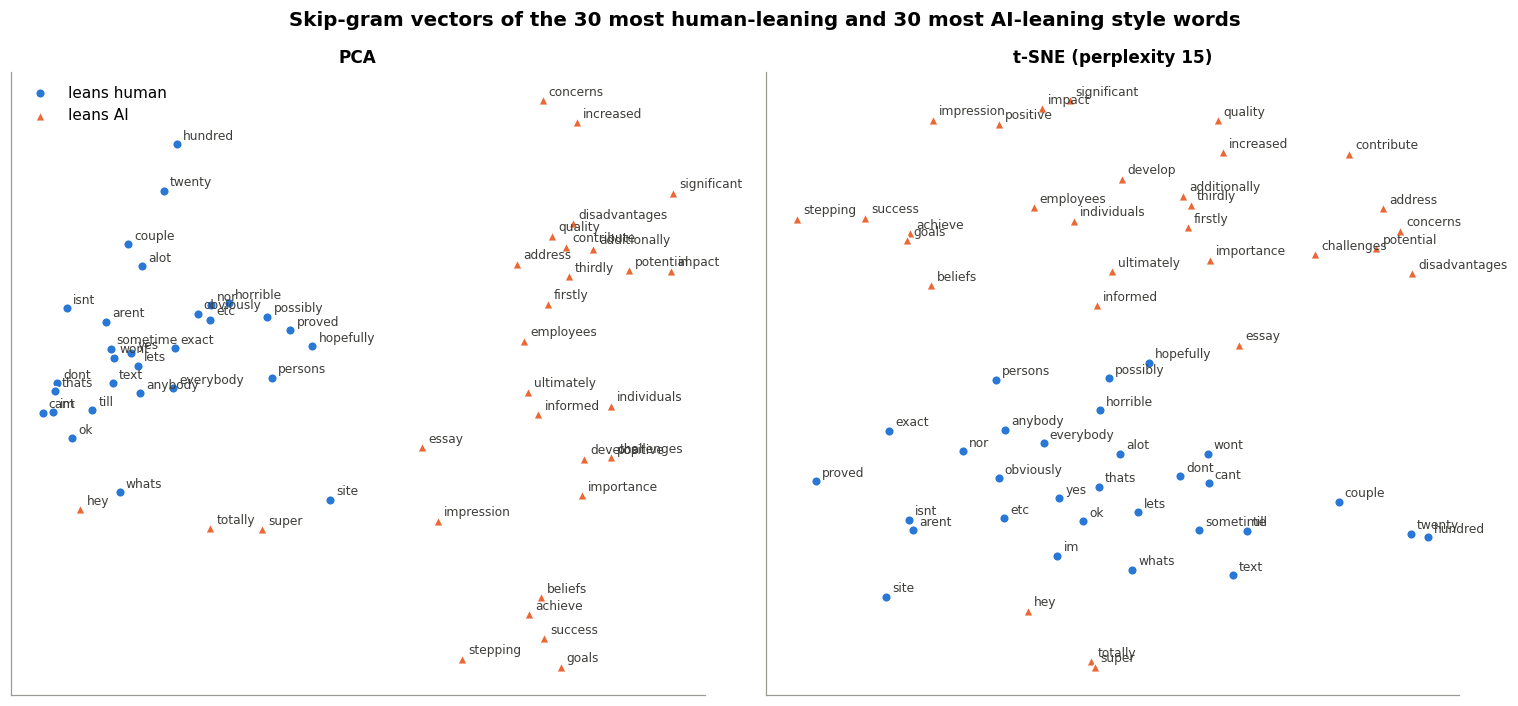

In [12]:
def word_map(kv, words, leans, title, path):
    X = np.vstack([kv[w] for w in words])
    pca_xy = PCA(n_components=2, random_state=SEED).fit_transform(X)
    tsne_xy = TSNE(n_components=2, perplexity=15, init='pca', random_state=SEED).fit_transform(X)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
    for ax, xy, sub in [(axes[0], pca_xy, 'PCA'), (axes[1], tsne_xy, 't-SNE (perplexity 15)')]:
        for is_ai, color, marker, label in [(False, HUMAN, 'o', 'leans human'), (True, AI, '^', 'leans AI')]:
            m = leans > 0 if is_ai else leans <= 0
            ax.scatter(xy[m, 0], xy[m, 1], s=40, c=color, marker=marker, label=label,
                       edgecolors='white', linewidths=1, zorder=3)
            for (x, y), w in zip(xy[m], np.array(words)[m]):
                ax.annotate(w, (x, y), xytext=(4, 3), textcoords='offset points', fontsize=8, color='#3d3d3a')
        ax.set_title(sub, fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
    axes[0].legend(loc='best', frameon=False)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

word_map(w2v['Skip-gram'], list(lean.index), lean.values,
         'Skip-gram vectors of the 30 most human-leaning and 30 most AI-leaning style words',
         '../images/05_word_map_skipgram.png')

**5b. Whole essays.** Represent each essay by the **average** of its word vectors (Step 6 explains why). Plot 2,000 `val` essays, coloured by their true label. Again, no label was used to build these vectors.

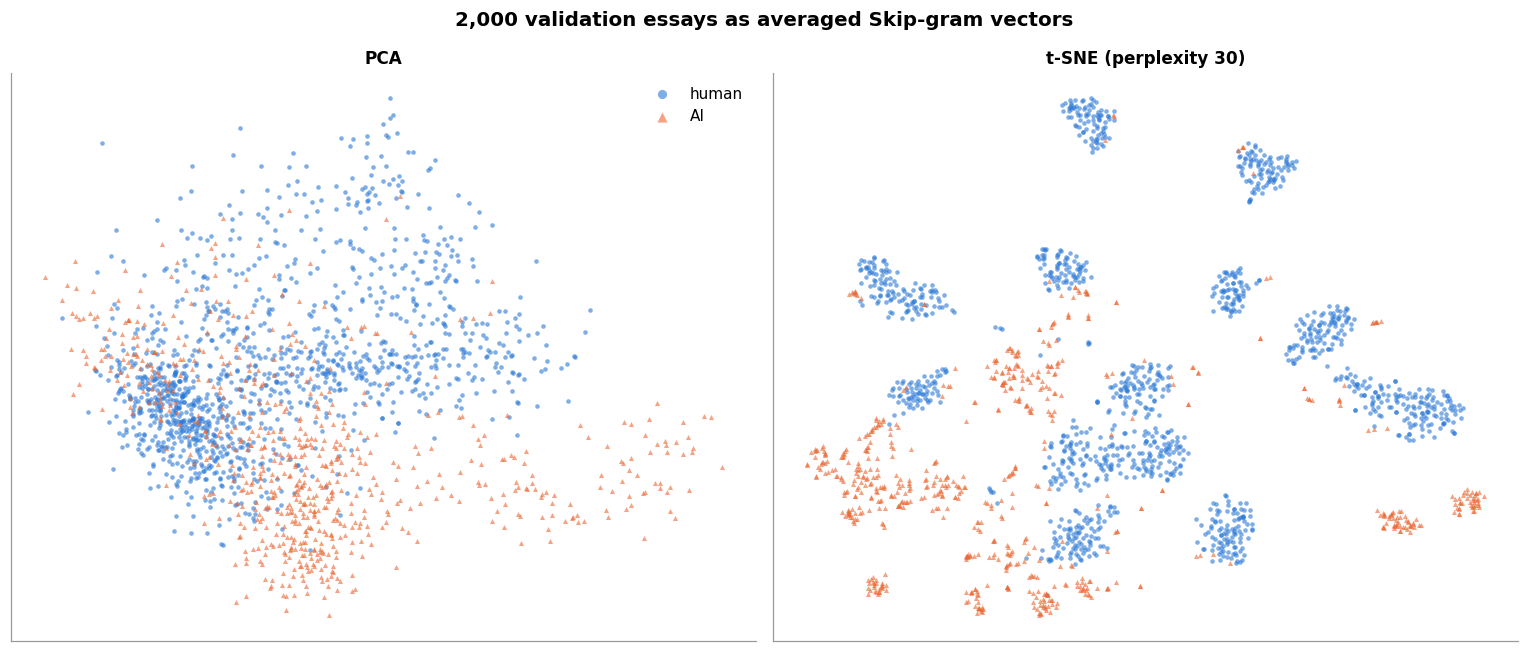

In [13]:
def doc_vectors(kv, token_lists):
    out = np.zeros((len(token_lists), kv.vector_size), dtype=np.float32)
    for i, toks in enumerate(token_lists):
        known = [w for w in toks if w in kv.key_to_index]
        if known:
            out[i] = kv[known].mean(axis=0)
    return out

sample = val.sample(2000, random_state=SEED)
Xs = doc_vectors(w2v['Skip-gram'], sample['tokens'].tolist())
is_ai = sample['label'].values == 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, xy, sub in [(axes[0], PCA(n_components=2, random_state=SEED).fit_transform(Xs), 'PCA'),
                    (axes[1], TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(Xs),
                     't-SNE (perplexity 30)')]:
    ax.scatter(xy[~is_ai, 0], xy[~is_ai, 1], s=9, c=HUMAN, marker='o', alpha=0.6, linewidths=0, label='human')
    ax.scatter(xy[is_ai, 0], xy[is_ai, 1], s=11, c=AI, marker='^', alpha=0.6, linewidths=0, label='AI')
    ax.set_title(sub, fontsize=11); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(frameon=False, markerscale=2)
fig.suptitle('2,000 validation essays as averaged Skip-gram vectors', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig('../images/05_essay_map_skipgram.png', dpi=150, bbox_inches='tight')
plt.show()

The two classes separate well, and t-SNE shows many tight clusters. Colour the same t-SNE by prompt to see what the clusters are:

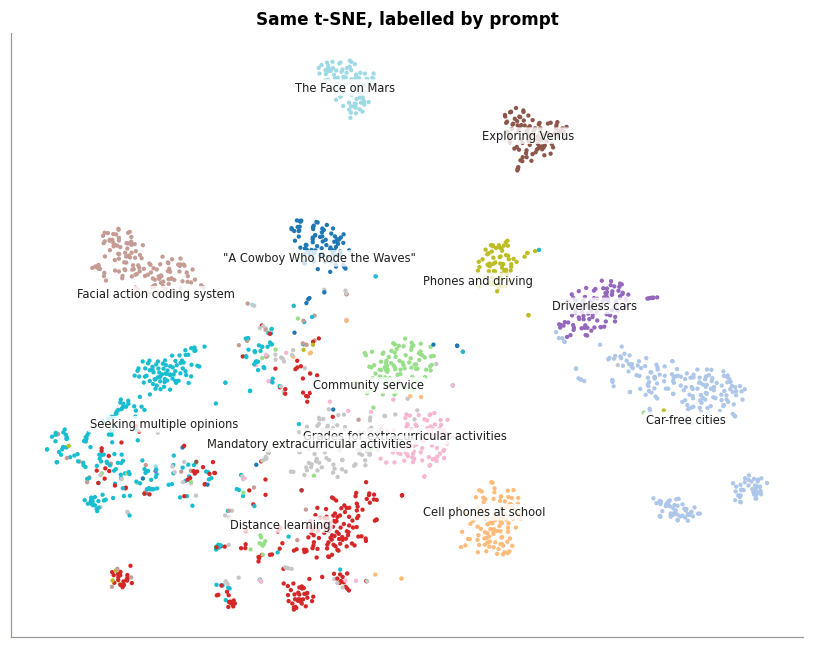

In [14]:
xy = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(Xs)
prompt_codes = sample['prompt_name'].astype('category').cat.codes
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(xy[:, 0], xy[:, 1], s=8, c=prompt_codes, cmap='tab20', linewidths=0)
for p in sample['prompt_name'].unique():
    m = (sample['prompt_name'] == p).values
    ax.annotate(p, xy[m].mean(axis=0), fontsize=7.5, ha='center', color='#1f1f1d',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8))
ax.set_title('Same t-SNE, labelled by prompt', fontsize=11); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig.savefig('../images/05_essay_map_by_prompt.png', dpi=150, bbox_inches='tight')
plt.show()

(This plot uses 13 colours only to show *that* topics form clusters; the labels, not the colours, say which is which.)

The tight clusters are **prompts**: topic is the strongest structure in an averaged embedding. Human essays form one clean cluster per prompt. The diffuse, mixed region (*Seeking multiple opinions*, *Distance learning*, *Mandatory extracurricular*…) is where the off-topic AI essays sit, which are labelled with those prompts but about other things.

## Step 6 — Classifier on averaged embeddings

The simplest way to turn word vectors into an essay vector is to **average** them ("mean pooling"):
- Every essay becomes one 100-number vector, whatever its length.
- **Word order is thrown away** (as in TF-IDF), and so is how *often* distinctive words appear relative to others: one "additionally" in 400 words barely moves the average.

On top: standardise each dimension, then logistic regression, with `C` tuned on `val` exactly as in `04`. The comparison with TF-IDF's ~200,000 sparse features vs these 100 dense ones is the point.

In [15]:
doc_X = {}
for name, kv in models.items():
    t0 = time.time()
    doc_X[name] = doc_vectors(kv, data['tokens'].tolist())     # every essay, rows aligned with `data`
    print(f"{name:10s} essay vectors in {time.time() - t0:.0f}s")

rows_of = lambda d: data.index.get_indexer(d.index)

tuning, fitted = [], {}
for name in models:
    X_tr, X_va = doc_X[name][rows_of(train)], doc_X[name][rows_of(val)]
    for C in [0.01, 0.1, 1, 10]:
        clf = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=3000)).fit(X_tr, train['label'])
        auc = roc_auc_score(val['label'], clf.predict_proba(X_va)[:, 1])
        tuning.append({'embedding': name, 'C': C, 'val_auc': auc})
        if auc >= max([t['val_auc'] for t in tuning if t['embedding'] == name]):
            fitted[name] = (C, clf)
pd.DataFrame(tuning).pivot(index='C', columns='embedding', values='val_auc').round(4)

CBOW       essay vectors in 48s


Skip-gram  essay vectors in 48s


GloVe      essay vectors in 52s


embedding,CBOW,GloVe,Skip-gram
C,,,
0.01,0.9907,0.9817,0.9915
0.10,0.9923,0.9834,0.9934
1.00,0.9924,0.9833,0.9939
10.00,0.9923,0.9832,0.9939


Score each embedding's best model once on the final sets, using the shared `src/evaluate.py` (the same logic as `04`), and put the rows next to the Week 1 results.

In [16]:
results = []
for name, (C, clf) in fitted.items():
    score = lambda d, clf=clf, name=name: clf.predict_proba(doc_X[name][rows_of(d)])[:, 1]
    results.append(evaluate(score, 0.5, f'avg {name} + LogReg (C={C:g})', test, ho_prompt, ho_gen))
emb_table = pd.DataFrame(results)

week1 = pd.read_csv('../results/04_baseline.csv', index_col=0)
pd.concat([week1, emb_table])[COLUMNS].round(3)

,test_acc,test_precision,test_recall,test_f1,test_auc,heldout_prompt_f1,heldout_prompt_auc,heldout_gen_detection,heldout_gen_auc
always human,0.654,0.000,0.000,0.000,0.500,0.000,0.500,0.000,0.500
length only (tree),0.673,1.000,0.054,0.103,0.719,0.032,0.726,0.002,0.750
prompt only,0.730,0.626,0.544,0.582,0.763,0.000,0.500,0.204,0.513
TF-IDF + LogReg (C=10),0.994,0.998,0.984,0.991,1.000,0.913,0.990,0.897,1.000
TF-IDF + LinearSVM (C=1),0.997,1.000,0.990,0.995,1.000,0.973,0.997,0.909,1.000
avg CBOW + LogReg (C=1),0.971,0.964,0.950,0.957,0.994,0.746,0.879,0.890,0.985
avg Skip-gram + LogReg (C=10),0.977,0.972,0.961,0.967,0.995,0.839,0.949,0.838,0.980
avg GloVe + LogReg (C=0.1),0.953,0.942,0.919,0.931,0.986,0.445,0.607,0.879,0.977


## Step 7 — Where averaging loses

Compare the most confident mistakes of the best embedding model on `test` with what TF-IDF caught. Read the essays: what is it missing?

In [17]:
best_name = max(fitted, key=lambda n: emb_table.loc[emb_table.index.str.contains(n), 'test_auc'].iloc[0])
C, clf = fitted[best_name]
t = test.assign(p_ai=clf.predict_proba(doc_X[best_name][rows_of(test)])[:, 1])
print(f"Best embedding model: {best_name}")
print(f"Test errors at 0.5: {((t['p_ai'] >= 0.5) != t['label']).sum()} of {len(t)}")
print("\nError rate by source on test (%):")
print(t.assign(wrong=(t['p_ai'] >= 0.5) != t['label']).groupby(['label', 'source'])['wrong'].mean().mul(100).round(1))
for title, rows in [("HUMAN essays scored most AI-like", t[t['label'] == 0].nlargest(2, 'p_ai')),
                    ("AI essays scored most human-like", t[t['label'] == 1].nsmallest(2, 'p_ai'))]:
    print(f"\n===== {title} =====")
    for _, r in rows.iterrows():
        print(f"[p_ai={r['p_ai']:.2f} | {r['source']} | {r['prompt_name']} | {r['n_words']} words]")
        print(r['text'][:400].replace('\n', ' '), '...')

Best embedding model: Skip-gram
Test errors at 0.5: 80 of 3501

Error rate by source on test (%):
label  source                            
0      persuade_corpus                        1.5
       train_essays                           0.0
1      NousResearch/Llama-2-7b-chat-hf        0.0
       chat_gpt_moth                          2.1
       cohere-command                        10.3
       kingki19_palm                          0.0
       llama2_chat                            1.5
       llama_70b_v1                           7.8
       mistral7binstruct_v1                   1.3
       mistral7binstruct_v2                  10.3
       mistralai/Mistral-7B-Instruct-v0.1     4.8
       palm-text-bison1                       0.0
       radek_500                              0.0
       radekgpt4                              0.0
Name: wrong, dtype: float64

===== HUMAN essays scored most AI-like =====
[p_ai=1.00 | persuade_corpus | Mandatory extracurricular activities | 378 words]
I agr

## Step 8 — Save

The results rows go to `results/05_embeddings.csv` (same columns as `04`). The trained Word2Vec vectors were saved to `models/` in Step 2; that folder is git-ignored, and Week 3's BiLSTM can initialise its embedding layer from them.

In [18]:
emb_table[COLUMNS].round(4).to_csv('../results/05_embeddings.csv')
print(open('../results/05_embeddings.csv').read())
print(sorted(os.listdir('../models')))

,test_acc,test_precision,test_recall,test_f1,test_auc,heldout_prompt_f1,heldout_prompt_auc,heldout_gen_detection,heldout_gen_auc
avg CBOW + LogReg (C=1),0.9706,0.964,0.9504,0.9571,0.9935,0.7463,0.8788,0.8901,0.985
avg Skip-gram + LogReg (C=10),0.9771,0.9724,0.9612,0.9667,0.9948,0.8389,0.9491,0.8379,0.9801
avg GloVe + LogReg (C=0.1),0.9526,0.9424,0.919,0.9305,0.9861,0.4445,0.6066,0.8787,0.9767

['w2v_cbow.kv', 'w2v_skipgram.kv']


## Key takeaways for Week 3

- **CBOW vs Skip-gram:** CBOW trained ~3× faster (32 s vs 94 s). CBOW's neighbours are *substitutes* ("car" → vehicle, automobile). Skip-gram's lean to *associates and rare forms* (misspellings like "studentss", "importent"), as expected from giving every rare word its own training signal.
- **Our Word2Vec vs GloVe:** GloVe knows the outside world, not our essays. Its nearest neighbours of "venus" are *tennis players* (Serena, Sharapova: Venus Williams), while ours are "planet", "nasa", "grinspoon" (the article's author). Domain matters more than corpus size.
- **Style is in the embedding space without labels.** Once topic words are filtered out (Step 5a), human-leaning words (informal; contractions typed without apostrophes: "dont", "isnt", "alot") and AI-leaning words (formal: "additionally", "significant", "potential", "firstly") fall in separate regions in both PCA and t-SNE. "hey", "super", "totally" lean AI: LLMs imitating a teenager's voice.
- **Data discovery: 7,570 of 17,493 AI essays (43%) are off-topic for their `prompt_name`.** They were generated from other prompts (Churchill quotes, honesty, first impressions…) and filed under the nearest of the 15 Persuade prompts. Human essays are ~85–100% on-topic. Topic is therefore a strong, meaningless shortcut, and `prompt_name` is unreliable for AI essays. Needs a decision before Week 3.
- **Averaged embeddings are worse than TF-IDF everywhere:** test AUC 0.986–0.995 vs 1.000. On held-out prompts they degrade badly: Skip-gram AUC 0.95, CBOW 0.88, **GloVe 0.61**. The t-SNE plots show why: an averaged vector mostly encodes *what the essay is about*, and topic doesn't transfer to unseen prompts. One "additionally" in 400 words barely moves the average.
- **Held-out-prompt numbers for these models move between runs** (Skip-gram F1 0.77 → 0.84 across two runs), because Word2Vec trains with 8 threads. Treat differences of a few points there as noise.
- **For Week 3 (BiLSTM):** keep word order instead of averaging, and initialise the embedding layer from `models/w2v_skipgram.kv` (in-domain, best of the three here). Score with `src/evaluate.py`, and compare on the held-out slices.
